# Session 30: Introduction to RNNs and LSTM
### Duration: ~2–2.5 Hours

---

## Session Goal

So far we modeled **tables** (Sessions 16–23) and **images** (Sessions 24–29).

Today we introduce **sequences** — data where **order matters**:

- Text (words in a sentence)
- Time series (values over time)
- Audio, sensor readings, click streams

We learn **Recurrent Neural Networks (RNN)** and **LSTM** — architectures that carry **memory** across steps.

## What Students Will Learn

- Sequences vs tabular vs image data
- How a basic RNN processes one step at a time
- LSTM for longer memory
- Text preprocessing: tokenize, vocabulary, padding
- PyTorch `Embedding` + `LSTM` + classifier head
- A **sklearn baseline** (TF-IDF + logistic regression) for comparison

> **Prerequisites:** Sessions 24–25 (neural network basics), Session 17 (classification metrics). Session 25 introduced RNN/LSTM conceptually — today we **implement** one.

> **Not in this session:** Transformers, BERT, attention, production NLP pipelines.

## Datasets

1. **Toy sine wave** — next-value prediction intuition
2. **20 Newsgroups (2 topics)** — text classification with LSTM



---
## 1. Why Sequences Are Different

| Data type | Order matters? | Models we used |
|-----------|----------------|----------------|
| Spreadsheet row | No | Random Forest, logistic regression |
| Image grid | Spatial, not time-ordered | CNN, transfer learning |
| **Sequence** | **Yes** | **RNN, LSTM** |

Examples where order matters:

```text
"I did not like the movie"  vs  "I did like the movie not"
```

Same words, different meaning — a bag-of-words model ignores order; sequence models do not.

### RNN idea (one sentence)

> At each time step, the network reads one input and updates a **hidden state** that summarizes what it has seen so far.



In [1]:
import warnings
import re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style='whitegrid', context='notebook', palette='colorblind')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUTPUT_DIR = Path('session30_artifacts')
OUTPUT_DIR.mkdir(exist_ok=True)

print('PyTorch:', torch.__version__)
print('Device:', DEVICE)



PyTorch: 2.12.1+cpu
Device: cpu


---
## 2. Toy Example — `nn.RNN` on a Sine Wave

We predict the **next value** in a short sequence. This shows the RNN API without text complexity.

```text
Input at each step: one number
Hidden state: summary of past values
Output: prediction for next step
```



In [2]:
def make_sine_sequences(n_series=200, seq_len=20):
    xs, ys = [], []
    x = np.linspace(0, 8 * np.pi, n_series + seq_len + 1)
    wave = np.sin(x)
    for i in range(n_series):
        xs.append(wave[i:i + seq_len])
        ys.append(wave[i + seq_len])
    return np.array(xs, dtype=np.float32), np.array(ys, dtype=np.float32)


X_seq, y_next = make_sine_sequences()
X_seq = X_seq[..., np.newaxis]  # (batch, seq_len, 1 feature)

X_tr, X_te, y_tr, y_te = train_test_split(X_seq, y_next, test_size=0.2, random_state=RANDOM_STATE)

X_tr_t = torch.tensor(X_tr)
y_tr_t = torch.tensor(y_tr).unsqueeze(1)
X_te_t = torch.tensor(X_te)
y_te_t = torch.tensor(y_te).unsqueeze(1)

rnn = nn.RNN(input_size=1, hidden_size=16, batch_first=True)

class SineRNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(input_size=1, hidden_size=16, batch_first=True)
        self.fc = nn.Linear(16, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        last = out[:, -1, :]
        return self.fc(last)


toy_model = SineRNN().to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(toy_model.parameters(), lr=0.01)

for epoch in range(1, 16):
    toy_model.train()
    optimizer.zero_grad()
    pred = toy_model(X_tr_t.to(DEVICE))
    loss = criterion(pred, y_tr_t.to(DEVICE))
    loss.backward()
    optimizer.step()
    if epoch % 5 == 0:
        toy_model.eval()
        with torch.no_grad():
            te_loss = criterion(toy_model(X_te_t.to(DEVICE)), y_te_t.to(DEVICE)).item()
        print(f'Epoch {epoch:02d} | train MSE {loss.item():.4f} | test MSE {te_loss:.4f}')

toy_model.eval()
with torch.no_grad():
    sample_pred = toy_model(X_te_t[:1].to(DEVICE)).cpu().item()
print('Example true next value:', y_te[0].round(3), '| predicted:', round(sample_pred, 3))



Epoch 05 | train MSE 0.1467 | test MSE 0.0993
Epoch 10 | train MSE 0.0539 | test MSE 0.0271
Epoch 15 | train MSE 0.0321 | test MSE 0.0353
Example true next value: 0.541 | predicted: 0.356


---
## 3. Text Classification — Load Data

We use **20 Newsgroups** with two topics:

| Class | Topic |
|-------|-------|
| 0 | `rec.sport.baseball` |
| 1 | `sci.space` |

This needs an internet connection the first time sklearn downloads the dataset.



In [3]:
CATEGORIES = ['rec.sport.baseball', 'sci.space']
MAX_SAMPLES_PER_CLASS = 400

raw_train = fetch_20newsgroups(
    subset='train', categories=CATEGORIES, remove=('headers', 'footers', 'quotes'),
)
raw_test = fetch_20newsgroups(
    subset='test', categories=CATEGORIES, remove=('headers', 'footers', 'quotes'),
)


def subsample_texts(texts, labels, per_class, seed=42):
    rng = np.random.default_rng(seed)
    idx = []
    for cls in sorted(set(labels)):
        cls_idx = np.where(np.array(labels) == cls)[0]
        pick = rng.choice(cls_idx, size=min(per_class, len(cls_idx)), replace=False)
        idx.extend(pick.tolist())
    rng.shuffle(idx)
    return [texts[i] for i in idx], [labels[i] for i in idx]


train_texts, train_labels = subsample_texts(raw_train.data, raw_train.target, MAX_SAMPLES_PER_CLASS)
test_texts, test_labels = subsample_texts(raw_test.data, raw_test.target, 150, seed=43)

label_names = raw_train.target_names
print('Train size:', len(train_texts))
print('Test size:', len(test_texts))
print('Classes:', label_names)
print('\nSample text snippet:\n', train_texts[0][:300], '...')



Train size: 800
Test size: 300
Classes: ['rec.sport.baseball', 'sci.space']

Sample text snippet:
 

        Let us hope that the performance of the spacecraft follows the
sentiments of the first verse (miner) rather than the second (lost and gone
forever).
 ...


---
## 4. Text Preprocessing for Deep Learning

Steps:

1. **Tokenize** — split text into words
2. **Build vocabulary** — map words to integer IDs
3. **Encode** — convert each document to a list of IDs
4. **Pad / truncate** — make all sequences the same length for batching

Special tokens:

| Token | ID | Purpose |
|-------|-----|---------|
| `<pad>` | 0 | Fill shorter sequences |
| `<unk>` | 1 | Unknown words |



In [4]:
TOKEN_PATTERN = re.compile(r"[a-zA-Z']+")
MAX_VOCAB = 8000
MAX_LEN = 150


def tokenize(text: str) -> list[str]:
    return [t.lower() for t in TOKEN_PATTERN.findall(text)]


def build_vocab(texts, max_vocab=MAX_VOCAB):
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))
    most_common = counter.most_common(max_vocab - 2)
    stoi = {'<pad>': 0, '<unk>': 1}
    for word, _ in most_common:
        stoi[word] = len(stoi)
    itos = {i: w for w, i in stoi.items()}
    return stoi, itos


def encode_text(text, stoi, max_len=MAX_LEN):
    tokens = tokenize(text)
    ids = [stoi.get(tok, 1) for tok in tokens[:max_len]]
    if len(ids) < max_len:
        ids += [0] * (max_len - len(ids))
    return ids


stoi, itos = build_vocab(train_texts)
print('Vocabulary size:', len(stoi))

train_ids = [encode_text(t, stoi) for t in train_texts]
test_ids = [encode_text(t, stoi) for t in test_texts]

print('Encoded length:', len(train_ids[0]))
print('First 12 token ids:', train_ids[0][:12])



Vocabulary size: 8000
Encoded length: 150
First 12 token ids: [382, 97, 498, 11, 2, 631, 4, 2, 160, 2113, 2, 7190]


---
## 5. PyTorch Dataset and LSTM Classifier

Architecture:

```text
Token IDs -> Embedding -> LSTM -> last hidden state -> Linear -> class logits
```

We use the **last time step** output for sentence-level classification.



In [5]:
class TextDataset(Dataset):
    def __init__(self, encoded_docs, labels):
        self.x = torch.tensor(encoded_docs, dtype=torch.long)
        self.y = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=64, num_classes=2, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        emb = self.embedding(x)
        out, (h_n, _) = self.lstm(emb)
        last_hidden = h_n[-1]
        return self.fc(self.dropout(last_hidden))


train_ds = TextDataset(train_ids, train_labels)
test_ds = TextDataset(test_ids, test_labels)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

model = LSTMClassifier(vocab_size=len(stoi), num_classes=len(CATEGORIES)).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model.__class__.__name__, 'ready')



LSTMClassifier ready


---
## 6. Training Loop



In [11]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        if is_train:
            optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        if is_train:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * yb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        total += yb.size(0)

    return total_loss / total, correct / total


EPOCHS = 10
history = []
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
    te_loss, te_acc = run_epoch(model, test_loader, criterion)
    history.append({'epoch': epoch, 'train_acc': tr_acc, 'test_acc': te_acc})
    print(f'Epoch {epoch:02d} | train acc {tr_acc:.3f} | test acc {te_acc:.3f}')

history_df = pd.DataFrame(history)



Epoch 01 | train acc 0.631 | test acc 0.510
Epoch 02 | train acc 0.625 | test acc 0.513
Epoch 03 | train acc 0.642 | test acc 0.503
Epoch 04 | train acc 0.630 | test acc 0.530
Epoch 05 | train acc 0.641 | test acc 0.520
Epoch 06 | train acc 0.608 | test acc 0.517
Epoch 07 | train acc 0.659 | test acc 0.530
Epoch 08 | train acc 0.627 | test acc 0.527
Epoch 09 | train acc 0.655 | test acc 0.567
Epoch 10 | train acc 0.685 | test acc 0.560


---
## 7. Evaluate the LSTM



LSTM test accuracy: 0.56

Classification report:
                    precision    recall  f1-score   support

rec.sport.baseball       0.54      0.74      0.63       150
         sci.space       0.59      0.38      0.46       150

          accuracy                           0.56       300
         macro avg       0.57      0.56      0.55       300
      weighted avg       0.57      0.56      0.55       300



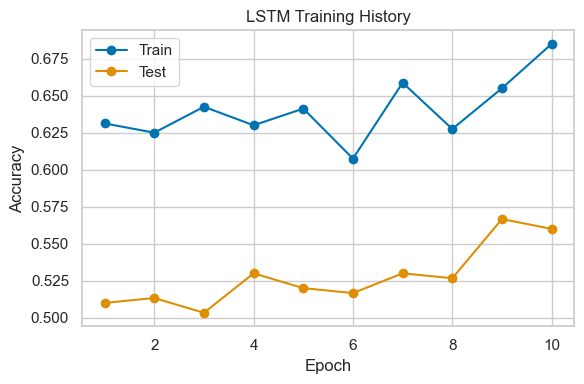

In [12]:
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        logits = model(xb.to(DEVICE))
        all_preds.extend(logits.argmax(1).cpu().tolist())
        all_true.extend(yb.tolist())

print('LSTM test accuracy:', round(accuracy_score(all_true, all_preds), 3))
print('\nClassification report:')
print(classification_report(all_true, all_preds, target_names=label_names))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history_df['epoch'], history_df['train_acc'], marker='o', label='Train')
ax.plot(history_df['epoch'], history_df['test_acc'], marker='o', label='Test')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('LSTM Training History')
ax.legend()
plt.tight_layout()
plt.show()



---
## 8. Baseline — TF-IDF + Logistic Regression

Always compare deep models to a **simple classical baseline** (Sessions 17, 23).

If the baseline is close, a big LSTM may not be worth the complexity.



In [13]:
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(train_texts)
X_test_tfidf = tfidf.transform(test_texts)

lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train_tfidf, train_labels)
lr_preds = lr.predict(X_test_tfidf)

print('TF-IDF + Logistic Regression accuracy:', round(accuracy_score(test_labels, lr_preds), 3))

compare = pd.DataFrame({
    'model': ['TF-IDF + LogisticRegression', 'LSTM'],
    'test_accuracy': [
        accuracy_score(test_labels, lr_preds),
        accuracy_score(all_true, all_preds),
    ],
})
print('\n', compare.to_string(index=False))



TF-IDF + Logistic Regression accuracy: 0.917

                       model  test_accuracy
TF-IDF + LogisticRegression       0.916667
                       LSTM       0.560000


---
## 9. RNN vs LSTM vs Transformers (Where This Course Stops)

| Model | Memory | Typical use today |
|-------|--------|-----------------|
| **RNN** | Short sequences | Teaching, tiny tasks |
| **LSTM / GRU** | Better long memory | Older NLP, some time series |
| **Transformer** | Attention over full sequence | Modern NLP, LLMs |

Most production text systems use **pretrained transformers** (BERT, GPT-style models). LSTM is still worth learning because it teaches **sequential processing** clearly.

### When sequences appear in real work

```text
Customer support ticket routing (text)
Demand forecasting (time series)
Fraud sequences (event logs)
```

---

## Practice Exercises

1. Change `MAX_LEN` to 80 vs 200 — how does LSTM accuracy change?
2. Increase `hidden_dim` to 128 — overfit faster?
3. Try **3 classes** from 20 Newsgroups — what happens to accuracy?
4. Predict on a **custom sentence** you write about baseball or space.
5. Why does TF-IDF sometimes beat LSTM on small data?

---

## Session 30 Summary

| Topic | Key takeaway |
|-------|--------------|
| **Sequences** | Order matters — different from tables and images |
| **RNN** | Hidden state carries information across steps |
| **LSTM** | Stronger memory for text classification |
| **Text prep** | Tokenize, vocab, pad before `Embedding` |
| **Baseline** | Compare LSTM to TF-IDF + logistic regression |

### Key gotchas

- **Small data** — LSTM may underperform classical text models
- **Padding** — use `padding_idx=0` in `Embedding`
- **Vocabulary** — build from **train only** to avoid leakage
- **Transformers** — state of the art for NLP, but more complex

### Next Session

**Session 31 — LLMs, Generative AI, RAG & Agentic AI:** the modern NLP stack after LSTM — transformers, prompting, retrieval-augmented generation, and tool-using agents. **Final session of the course.**

